# Analiza danych używając statystycznej kontroli procesu

Ten zeszyt przedstawia analizę danych zawartych w [Predictive Maintenance Dataset (AI4I 2020)](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020). Na podstawie ich sporządzone zostały karty kontrolne x-R i obliczone zostały wskaźniki zdolności procesu (Cp i Cpk).

Tabelka zawiera wiele różnych typów danych. Od ID produkowanego dobra, po temperaturę, moment obrotowy aż po indykatory awarii maszyn. Podgląd jest widoczny poniżej:

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('ai4i2020.csv')
pd.set_option('display.max_columns', None)
print(df.head())
print(df.describe())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

Wybieramy zmienną która przedstawia rezultaty ciągłego procesu maszyn. Dla naszego przykładu wybrałem moment obrotowy, czyli "Torque [Nm]".
Następnie musimy wyznaczyć liczbę klas i rozmiar próbki, którą mierzymy. Aby wyniki były wystarczająco czytelne i użyteczne wybrałem stosunkowo małą próbkę 20 klas po 10 sztuk, 200 w sumie.
Dla tej liczby klas dobieramy stałe d_2, d_3 i d_4 używając tabelki:

![Tabela z danymi](tabela.png)

Z tymi danymi możemy obliczyć wartości średniej x (w programie x_bar) i rostępu. Obie wartości obliczamy dla każdej klasy osobno.

In [ ]:
d_2 = 3.735
d_3 = 0.415
d_4 = 1.585

subgroup_size = 10
subgroup_num = 20
sample_size = subgroup_size * subgroup_num

x_bar = [df['Torque [Nm]']
        .values[i:i+subgroup_size]
        .mean(axis=0)
        for i in range(0, sample_size, subgroup_size)]

r = [np.ptp(df['Torque [Nm]']
        .values[i:i+subgroup_size])
        for i in range(0, sample_size, subgroup_size)]

Mając średnie x, rostępy R i wszystkie stałe możemy obliczyć górne i dolne linie kontrolne (GLK i DLK, w programie jako odpowiednio ucl, lcl) dla x za równo jak dla R używając tych wzorów:
$$
GLK_R = D_4 \overline{R}
$$

$$
DLK_R = D_3 \overline{R}
$$

$$
GLK_{\overline{x}} =\overline{\overline{x}} + 3 \frac{\overline{R}}{d_2 \sqrt{k}}
$$

$$
DLK_{\overline{x}} =\overline{\overline{x}} - 3 \frac{\overline{R}}{d_2 \sqrt{k}}
$$

gdzie k jest równa liczbie klas.

In [ ]:
r_mean = np.mean(r)
ucl_r = d_4 * r_mean
lcl_r = d_3 * r_mean

x_bar_mean = np.mean(x_bar)
ucl_x_bar = x_bar_mean + 3 * r_mean / (d_2 * np.sqrt(sample_size))
lcl_x_bar = x_bar_mean - 3 * r_mean / (d_2 * np.sqrt(sample_size))

print(ucl_r, lcl_r)
print(ucl_x_bar, lcl_x_bar)

48.477225 12.692774999999997
41.61759726125226 38.14340273874775


Wyniki tych obliczeń zaprezentowane są na dwóch wykresach poniżej.

Wykres 1: Zależność rozrzutów R każdej klasy do górnej i dolnej linii kontrolnej.

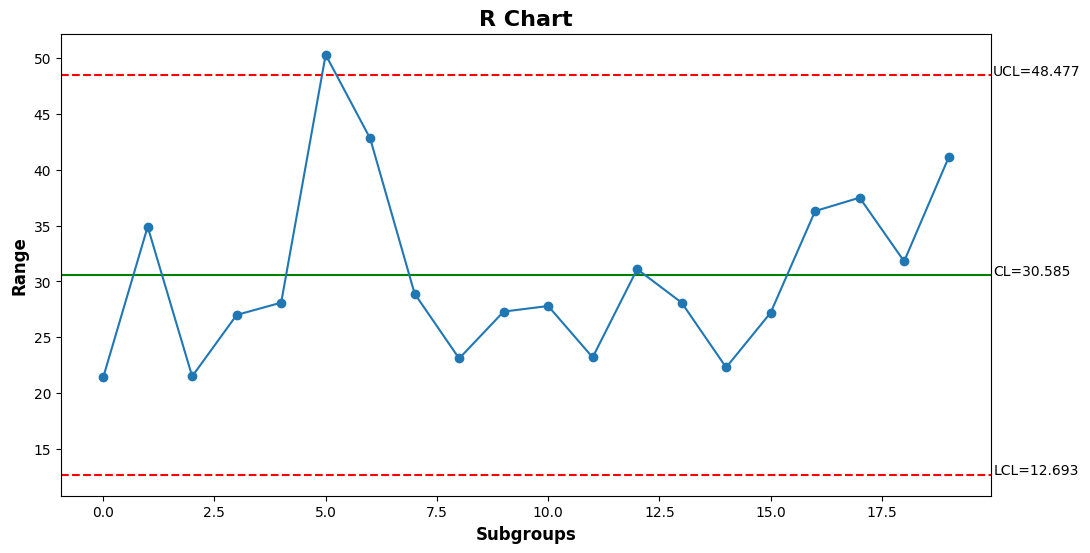

In [31]:
#plot r chart
plt.figure(1, figsize=(12, 6))
plt.axhline(y=r_mean, color='g', linestyle='-', label='Overall Range Mean')
plt.axhline(y=ucl_r, color='r', linestyle='--', label='UCL')
plt.axhline(y=lcl_r, color='r', linestyle='--', label='LCL')
plt.plot(r, marker='o')
plt.title('R Chart', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xlabel('Subgroups', fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.ylabel('Range', fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.text(20, ucl_r, f'UCL={round(ucl_r, 3)}')
plt.text(20, lcl_r, f'LCL={round(lcl_r, 3)}')
plt.text(20, r_mean, f'CL={round(r_mean, 3)}')
plt.show()

Wykres 2: Zależność średnich x każdej klasy do górnej i dolnej linii kontrolnej.

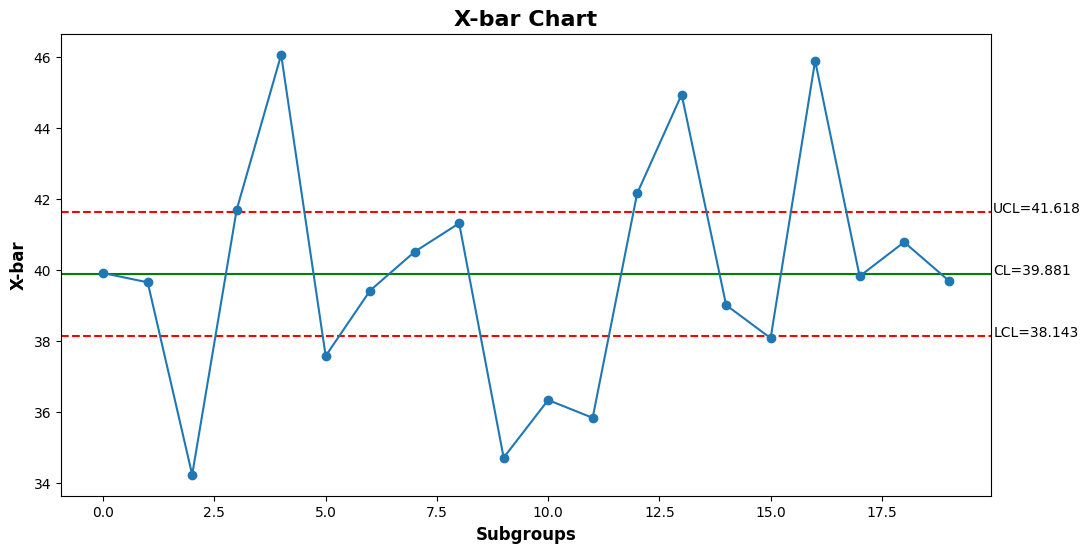

In [32]:
#x_mean chart
plt.figure(2, figsize=(12, 6))
plt.axhline(y=x_bar_mean, color='g', linestyle='-', label='Overall Mean')
plt.axhline(y=ucl_x_bar, color='r', linestyle='--', label='UCL')
plt.axhline(y=lcl_x_bar, color='r', linestyle='--', label='LCL')
plt.plot(x_bar, marker='o')
plt.title('X-bar Chart', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xlabel('Subgroups', fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.ylabel('X-bar', fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.text(20, ucl_x_bar, f'UCL={round(ucl_x_bar, 3)}')
plt.text(20, lcl_x_bar, f'LCL={round(lcl_x_bar, 3)}')
plt.text(20, x_bar_mean, f'CL={round(x_bar_mean, 3)}')
plt.show()

In [ ]:
#made up cuz we dont have real specs
usl = 60
lsl = 20
est_sigma = r_mean / d_2
cp = (usl - lsl) / (6 * est_sigma)
cpk = min((usl - x_bar_mean) / (3 * est_sigma), 
          (x_bar_mean - lsl) / (3 * est_sigma))
print(f'Cp: {round(cp, 3)}')
print(f'Cpk: {round(cpk, 3)}')

Cp: 0.814
Cpk: 0.809
